<a target="_blank" href="https://colab.research.google.com/github/cesarschoollectures/am-labs/blob/main/assignments/E01_Decision_Tree.ipynb">
<img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/>
</a>

# Aprendizado de Máquina

# Questão 1

Utilize o dataset Iris disponível no scikit-learn.
Divida os dados em treino e teste utilizando divisão estratificada.

**Solução**:

In [2]:
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split

iris = load_iris()
X = iris.data 
y = iris.target

X_train, X_test, y_train, y_test = train_test_split(
    X, y, 
    test_size=0.3,      
    random_state=42,    
    stratify=y          
)


print(f"tamanho do treino: {len(y_train)}")
print(f"tamanho do teste: {len(y_test)}")

tamanho do treino: 105
tamanho do teste: 45


# Questão 2

Treine um modelo utilizando `DecisionTreeClassifier`.

Depois calcule:

- acurácia no treino
- acurácia no teste

**Solução**:

In [5]:
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score

iris = load_iris()
X, y = iris.data, iris.target

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, stratify=y, random_state=42)

model = DecisionTreeClassifier(random_state=42)
model.fit(X_train, y_train)

train_acc = accuracy_score(y_train, model.predict(X_train))
test_acc = accuracy_score(y_test, model.predict(X_test))

print("Acurácia no treino:",train_acc)
print("Acurácia no teste:",test_acc)

Acurácia no treino: 1.0
Acurácia no teste: 0.9333333333333333


# Questão 3

Utilize `plot_tree()` para visualizar a árvore treinada.

Responda:

1. Qual atributo aparece na raiz?
2. Qual é a profundidade da árvore?

**Solução**:

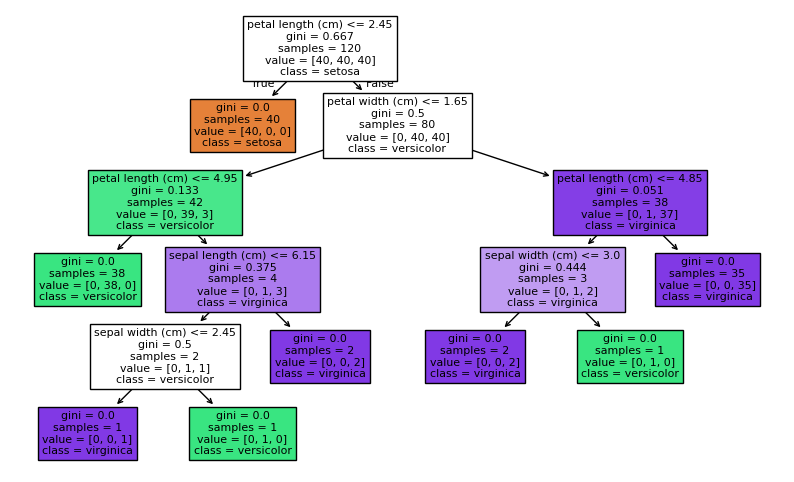

1 - O atributo na raiz pode ser visto no primeiro nó do gráfico :petal length (cm) 
2 - profundidade da árvore: 5


In [26]:
from sklearn.tree import plot_tree
import matplotlib.pyplot as plt

plt.figure(figsize=(10,6))
plot_tree(model, feature_names=iris.feature_names, class_names=iris.target_names, filled=True)
plt.show()

print("1 - O atributo na raiz pode ser visto no primeiro nó do gráfico :petal length (cm) \n2 - profundidade da árvore:",model.get_depth())

**Adicione seu texto de solução aqui**.

# Questão 4

Treine dez árvores com:

- max_depth = 1
- max_depth = 2
- max_depth = 3
...
- max_depth = 9
- max_depth = None

Registre em uma tabela para cada árvore:

- acurácia no treino
- acurácia no teste
- profundidade da árvore
- número de folhas

**Solução**:

In [8]:
import pandas as pd
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score

depths = [1,2,3,4,5,6,7,8,9,None]
dados = []

for d in depths:
    m = DecisionTreeClassifier(max_depth=d, random_state=42)
    m.fit(X_train, y_train)
    
    train_acc = accuracy_score(y_train, m.predict(X_train))
    test_acc = accuracy_score(y_test, m.predict(X_test))
    
    dados.append([
        d,
        train_acc,
        test_acc,
        m.get_depth(),
        m.get_n_leaves()
    ])

tabela = pd.DataFrame(dados, columns=[
    "max_depth",
    "acuracia_treino",
    "acuracia_teste",
    "profundidade",
    "num_folhas"
])

print(tabela)

   max_depth  acuracia_treino  acuracia_teste  profundidade  num_folhas
0        1.0         0.666667        0.666667             1           2
1        2.0         0.966667        0.933333             2           3
2        3.0         0.983333        0.966667             3           5
3        4.0         0.991667        0.933333             4           7
4        5.0         1.000000        0.933333             5           8
5        6.0         1.000000        0.933333             5           8
6        7.0         1.000000        0.933333             5           8
7        8.0         1.000000        0.933333             5           8
8        9.0         1.000000        0.933333             5           8
9        NaN         1.000000        0.933333             5           8


**Em qual profundidade começa o overfitting?**
**Por que a árvore consegue 100% no treino quando max_depth=None?**

Resposta: O overfitting começa mais ou menos a partir da profundidade 5, porque a acurácia no treino já fica muito alta e não muda mais muito, enquanto o modelo começa a ficar mais complexo sem melhorar realmente o resultado. Quando max_depth=None, não existe limite para a árvore crescer, então ela continua dividindo os dados até separar tudo perfeitamente, o que acaba gerando 100% de acerto no treino.

# Questão 5

Treine dois modelos:

- criterion = "gini"
- criterion = "entropy"

Compare:

- profundidade da árvore
- acurácia

**Solução**:

In [17]:
criterios = ["gini", "entropy"]
comparativo = []

for c in criterios:
    clf_comp = DecisionTreeClassifier(criterion=c, random_state=42)
    clf_comp.fit(X_train, y_train)
    
    comparativo.append({
        "Criterio": c,
        "Profundidade": clf_comp.get_depth(),
        "Acuracia_Teste": clf_comp.score(X_test, y_test)
    })

df_comparativo = pd.DataFrame(comparativo)
print(df_comparativo)

  Criterio  Profundidade  Acuracia_Teste
0     gini             5        0.933333
1  entropy             5        0.933333


# Questão 6

Escolha um hiperparâmetro e investigue seu impacto.

Sugestões:

- max_depth
- min_samples_split
- min_samples_leaf
- criterion

Mostre resultados e interprete.
- melhor modelo encontrado
- acurácia
- parâmetros

**Solução**:

In [20]:
import pandas as pd

impacto_folhas = []
valores_leaf = [1, 2, 5, 10, 20, 50]

for m in valores_leaf:
    clf_leaf = DecisionTreeClassifier(min_samples_leaf=m, random_state=42)
    clf_leaf.fit(X_train, y_train)
    
    impacto_folhas.append({
        "min_samples_leaf": m,
        "treino": clf_leaf.score(X_train, y_train),
        "teste": clf_leaf.score(X_test, y_test),
        "folhas_reais": clf_leaf.get_n_leaves()
    })

df_leaf = pd.DataFrame(impacto_folhas)
melhor_idx = df_leaf['teste'].idxmax()
melhor_modelo_info = df_leaf.loc[melhor_idx]

print(df_leaf)
print("\n--- Melhor Modelo Encontrado ---")
print(f"Melhor min_samples_leaf: {melhor_modelo_info['min_samples_leaf']}")
print(f"Acurácia no Teste: {melhor_modelo_info['teste']}")

   min_samples_leaf    treino     teste  folhas_reais
0                 1  1.000000  1.000000            10
1                 2  0.971429  1.000000             8
2                 5  0.942857  1.000000             6
3                10  0.942857  0.977778             5
4                20  0.942857  0.977778             4
5                50  0.647619  0.711111             2

--- Melhor Modelo Encontrado ---
Melhor min_samples_leaf: 1.0
Acurácia no Teste: 1.0
